# AI Romantic Relationship Simulator — Results

This notebook answers three questions:
1. **Do different personalities make different choices?**
2. **Do those choices produce different outcomes?**
3. **Does your *partner's* personality matter as much as your own?**

Run all cells top to bottom. Make sure you have a trained checkpoint at `data/checkpoints/latest.pt`.

In [1]:
import sys
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path(".").resolve()))  # run from project root

from src.env.marriage_env import MarriageEnv
from src.agents.agent import Agent
from src.env.events import ACTION_NAMES
from src.env.state import _TRAIT_NAMES, X_DIM

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

CONFIG = "config/default.yaml"
EVENTS = "config/events.yaml"
CKPT   = "data/checkpoints/latest.pt"

with open(CONFIG) as f:
    cfg = yaml.safe_load(f)

env        = MarriageEnv(CONFIG, EVENTS)
obs_dim    = env.observation_space.shape[0]
hidden_dim = cfg["training"]["hidden_dim"]
device     = torch.device("cpu")

agent_h = Agent(obs_dim, 5, hidden_dim, lr=1e-3, device=device, x_dim=X_DIM)
agent_w = Agent(obs_dim, 5, hidden_dim, lr=1e-3, device=device, x_dim=X_DIM)

ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
agent_h.policy.load_state_dict(ckpt["agent_h_policy"])
agent_h.value.load_state_dict(ckpt["agent_h_value"])
agent_w.policy.load_state_dict(ckpt["agent_w_policy"])
agent_w.value.load_state_dict(ckpt["agent_w_value"])
agent_h.policy.eval()
agent_w.policy.eval()

print(f"Checkpoint loaded — episode {ckpt['episode']}")
print(f"obs_dim={obs_dim}  hidden_dim={hidden_dim}")

Checkpoint loaded — episode 1000000
obs_dim=54  hidden_dim=128


In [2]:
# ── Archetypes & palette ───────────────────────────────────────────────────────
# Each archetype captures attachment theory: only definitional traits vary.
# All non-defining traits are fixed at 0.5 to eliminate confounding variables.
# Order: secure → emotional → rational → avoidant (best to worst attachment health)

ARCHETYPES = {
    "secure": dict(
        mental_stability=0.9, faithfulness=0.9, kindness=0.85,
        eq=0.85, ability_to_love=0.85, emotional_reasoning=0.75, responsibility=0.8,
        iq=0.5, rational_thinking=0.5,
    ),
    "emotional": dict(
        eq=0.85, emotional_reasoning=0.85, ability_to_love=0.9, mental_stability=0.3,
        iq=0.5, rational_thinking=0.5, kindness=0.5, faithfulness=0.5, responsibility=0.5,
    ),
    "rational": dict(
        iq=0.85, rational_thinking=0.85, eq=0.3, emotional_reasoning=0.25,
        kindness=0.5, faithfulness=0.5, responsibility=0.5,
        mental_stability=0.5, ability_to_love=0.5,
    ),
    "avoidant": dict(
        eq=0.2, ability_to_love=0.15, emotional_reasoning=0.2,
        mental_stability=0.25, faithfulness=0.35,
        iq=0.5, rational_thinking=0.5, kindness=0.5, responsibility=0.5,
    ),
}

ARCH_NAMES   = list(ARCHETYPES.keys())
ARCH_COLORS  = {"secure": "#8DC87A", "emotional": "#E8694C",
                "rational": "#4C9BE8", "avoidant": "#B07FD4"}
ACTION_COLORS = ["#4C9BE8", "#E8694C", "#8DC87A", "#F5C842", "#B07FD4"]

def _inject(traits_h, traits_w):
    for side, traits in [(env.x_h, traits_h), (env.x_w, traits_w)]:
        for attr, val in traits.items():
            setattr(side, attr, float(val))
        side.innate = np.array([traits.get(t, 0.5) for t in _TRAIT_NAMES], dtype=np.float32)


def _collect_episode(env, action_fn_h, action_fn_w, traits_h, traits_w):
    """
    Run one episode. action_fn_h/w: (obs) -> action int.
    Returns a record dict with trajectory + outcome fields.
    """
    env.reset()
    _inject(traits_h, traits_w)
    obs_h = env._get_obs("h")
    obs_w = env._get_obs("w")

    acts_h = []
    traj = {k: [] for k in ["happiness", "stability", "love_support",
                              "pressure", "trust_h", "resentment_h"]}
    done = False
    info = {}

    while not done:
        ah = action_fn_h(obs_h)
        aw = action_fn_w(obs_w)
        obs_h, _, done, _, info = env.step([ah, aw])
        obs_w = info["obs_w"]
        acts_h.append(ah)
        yh = info["y_state_h"]
        yw = info["y_state_w"]
        traj["love_support"].append((yh[1] + yw[1]) / 2)
        traj["pressure"].append((yh[2] + yw[2]) / 2)
        traj["happiness"].append((yh[3] + yw[3]) / 2)
        traj["stability"].append((yh[4] + yw[4]) / 2)
        traj["trust_h"].append(yh[5])
        traj["resentment_h"].append(yh[6])

    divorced = bool(info.get("divorced", False))
    n = len(acts_h)
    return {
        "happiness":    traj["happiness"][-1],
        "stability":    traj["stability"][-1],
        "love_support": traj["love_support"][-1],
        "pressure":     traj["pressure"][-1],
        "trust_h":      traj["trust_h"][-1],
        "resentment_h": traj["resentment_h"][-1],
        "divorced":     divorced,
        "action_dist":  [acts_h.count(i) / n for i in range(5)],
        "trajectory":   {k: np.array(v) for k, v in traj.items()},
    }


def run_pair(arch_h, arch_w, n_episodes=50, seed=0):
    """Trained policy. Same traits, same env — uses learned agent_h / agent_w."""
    np.random.seed(seed)
    th, tw = ARCHETYPES[arch_h], ARCHETYPES[arch_w]
    def act_h(obs): a, _, _ = agent_h.act(obs); return a
    def act_w(obs): a, _, _ = agent_w.act(obs); return a
    return [_collect_episode(env, act_h, act_w, th, tw) for _ in range(n_episodes)]


def run_pair_random(arch_h, arch_w, n_episodes=50, seed=0):
    """
    Random policy baseline. Same traits, same env — actions chosen uniformly at random.

    Comparing run_pair vs run_pair_random isolates the policy contribution:
        policy_effect = trained_outcome − random_outcome

    If this delta ≈ 0 → traits + mechanics drive results; policy is a passenger.
    If delta is meaningful → the agent learned something real.
    """
    np.random.seed(seed)
    th, tw = ARCHETYPES[arch_h], ARCHETYPES[arch_w]
    def act_random(_obs): return env.action_space.sample()[0]
    return [_collect_episode(env, act_random, act_random, th, tw) for _ in range(n_episodes)]

print("Helpers ready.")

Helpers ready.


---
## 0 — Ablation: does the trained policy actually matter?

**The key question:** are observed outcome differences driven by the *learned policy*,
or by the trait parameters and hardcoded mechanics alone?

We run the same 4 archetypes with the same environment twice:
- **Trained**: actions from the PPO policy
- **Random**: actions sampled uniformly (no policy)

`policy_contribution = trained_outcome − random_outcome`

- If contribution ≈ 0 → traits decide outcomes; policy is a passenger
- If contribution is meaningfully positive → the agent learned something real

The bar chart shows both side by side. The contribution panel shows the signed delta.

In [3]:
print("Running ablation — trained vs random policy (self-paired, 100 episodes each)...")
ablation_trained = {arch: run_pair(arch, arch, n_episodes=100, seed=7) for arch in ARCH_NAMES}
ablation_random  = {arch: run_pair_random(arch, arch, n_episodes=100, seed=7) for arch in ARCH_NAMES}
print("Done.")

Running ablation — trained vs random policy (self-paired, 100 episodes each)...


Done.


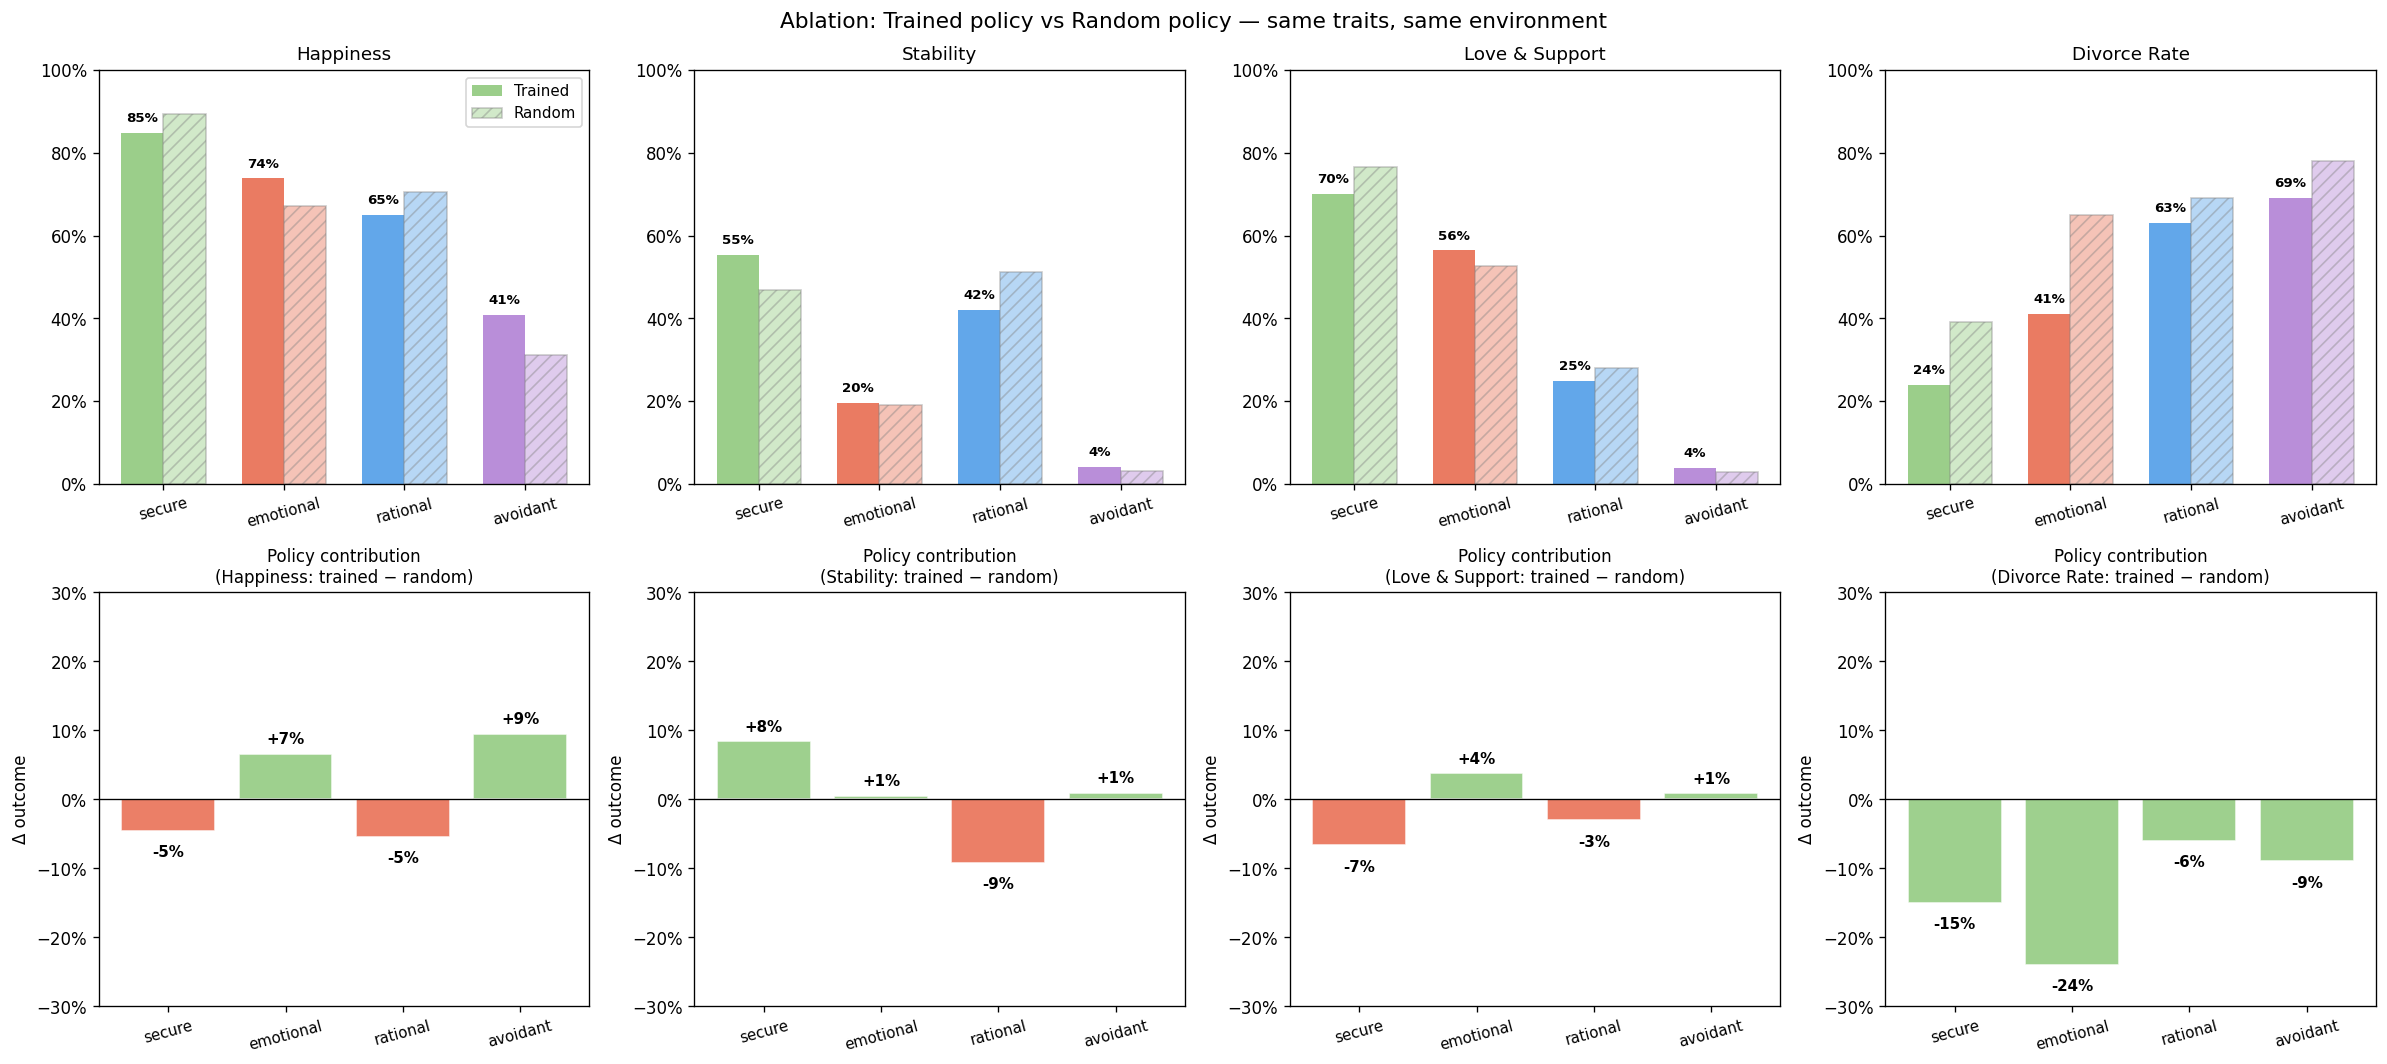


── Policy Contribution Summary ──
Archetype      Happiness   Stability  Love & Sup  Divorce Ra
───────────────────────────────────────────────────────
secure             -4.6%       +8.5%       -6.7%      -15.0%
emotional          +6.6%       +0.6%       +3.8%      -24.0%
rational           -5.5%       -9.2%       -3.1%       -6.0%
avoidant           +9.5%       +1.0%       +0.9%       -9.0%

Positive = trained beats random (green). Negative = random beats trained (red).
For divorce rate: negative is good (trained divorces less).


In [4]:
ABL_METRICS = ["happiness", "stability", "love_support", "divorced"]
ABL_LABELS  = ["Happiness", "Stability", "Love & Support", "Divorce Rate"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Ablation: Trained policy vs Random policy — same traits, same environment",
             fontsize=13)

x      = np.arange(len(ARCH_NAMES))
width  = 0.35
colors = [ARCH_COLORS[a] for a in ARCH_NAMES]

# ── Top row: side-by-side bars (trained vs random) ───────────────────────────
for ax, metric, label in zip(axes[0], ABL_METRICS, ABL_LABELS):
    survivors_t = {a: [r for r in ablation_trained[a] if not r["divorced"]] for a in ARCH_NAMES}
    survivors_r = {a: [r for r in ablation_random[a]  if not r["divorced"]] for a in ARCH_NAMES}

    if metric == "divorced":
        vals_t = [np.mean([r["divorced"] for r in ablation_trained[a]]) for a in ARCH_NAMES]
        vals_r = [np.mean([r["divorced"] for r in ablation_random[a]])  for a in ARCH_NAMES]
    else:
        vals_t = [np.mean([r[metric] for r in survivors_t[a]]) if survivors_t[a] else 0 for a in ARCH_NAMES]
        vals_r = [np.mean([r[metric] for r in survivors_r[a]]) if survivors_r[a] else 0 for a in ARCH_NAMES]

    bars_t = ax.bar(x - width/2, vals_t, width, label="Trained",
                    color=colors, alpha=0.88)
    bars_r = ax.bar(x + width/2, vals_r, width, label="Random",
                    color=colors, alpha=0.40, hatch="///", edgecolor="grey")

    ax.set_xticks(x)
    ax.set_xticklabels(ARCH_NAMES, rotation=15, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    if ax is axes[0][0]:
        ax.legend(fontsize=9)

    # Annotate trained bars
    for bar, val in zip(bars_t, vals_t):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f"{val:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── Bottom row: policy contribution = trained − random ───────────────────────
for ax, metric, label in zip(axes[1], ABL_METRICS, ABL_LABELS):
    survivors_t = {a: [r for r in ablation_trained[a] if not r["divorced"]] for a in ARCH_NAMES}
    survivors_r = {a: [r for r in ablation_random[a]  if not r["divorced"]] for a in ARCH_NAMES}

    if metric == "divorced":
        vals_t = [np.mean([r["divorced"] for r in ablation_trained[a]]) for a in ARCH_NAMES]
        vals_r = [np.mean([r["divorced"] for r in ablation_random[a]])  for a in ARCH_NAMES]
        contribs = [t - r for t, r in zip(vals_t, vals_r)]
        # For divorce: negative contribution means policy reduces divorce — good
        bar_colors = ["#E8694C" if c > 0 else "#8DC87A" for c in contribs]
    else:
        vals_t = [np.mean([r[metric] for r in survivors_t[a]]) if survivors_t[a] else 0 for a in ARCH_NAMES]
        vals_r = [np.mean([r[metric] for r in survivors_r[a]]) if survivors_r[a] else 0 for a in ARCH_NAMES]
        contribs = [t - r for t, r in zip(vals_t, vals_r)]
        bar_colors = ["#8DC87A" if c > 0 else "#E8694C" for c in contribs]

    bars = ax.bar(x, contribs, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(ARCH_NAMES, rotation=15, fontsize=9)
    ax.set_ylim(-0.3, 0.3)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(f"Policy contribution\n({label}: trained − random)", fontsize=10)
    ax.set_ylabel("Δ outcome")

    for bar, c in zip(bars, contribs):
        ax.text(bar.get_x() + bar.get_width()/2,
                c + (0.01 if c >= 0 else -0.02),
                f"{c:+.0%}", ha="center", va="bottom" if c >= 0 else "top",
                fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("data/0_ablation_trained_vs_random.png", dpi=120)
plt.show()

# ── Print verdict ─────────────────────────────────────────────────────────────
print("\n── Policy Contribution Summary ──")
print(f"{'Archetype':<12}", end="")
for label in ABL_LABELS:
    print(f"  {label[:10]:>10}", end="")
print()
print("─" * 55)

for arch in ARCH_NAMES:
    surv_t = [r for r in ablation_trained[arch] if not r["divorced"]]
    surv_r = [r for r in ablation_random[arch]  if not r["divorced"]]
    print(f"{arch:<12}", end="")
    for metric in ABL_METRICS:
        if metric == "divorced":
            t = np.mean([r["divorced"] for r in ablation_trained[arch]])
            r_ = np.mean([r["divorced"] for r in ablation_random[arch]])
        else:
            t  = np.mean([r[metric] for r in surv_t]) if surv_t else 0
            r_ = np.mean([r[metric] for r in surv_r]) if surv_r else 0
        print(f"  {t-r_:>+10.1%}", end="")
    print()

print("\nPositive = trained beats random (green). Negative = random beats trained (red).")
print("For divorce rate: negative is good (trained divorces less).")

---
## 1 — What does each personality choose?

We lock both agents to the same archetype and run 50 episodes.
The bar chart shows how often each personality reaches for each action.

**What to look for:** emotional agents should lean on `support`, rational agents on `compromise`, avoidant agents on `ignore`/`withdraw`, secure agents on a healthy mix of `support` + `compromise`.

In [5]:
print("Running self-paired episodes (this takes ~30s)...")
self_pairs = {arch: run_pair(arch, arch, n_episodes=50) for arch in ARCH_NAMES}
print("Done.")

Running self-paired episodes (this takes ~30s)...


Done.


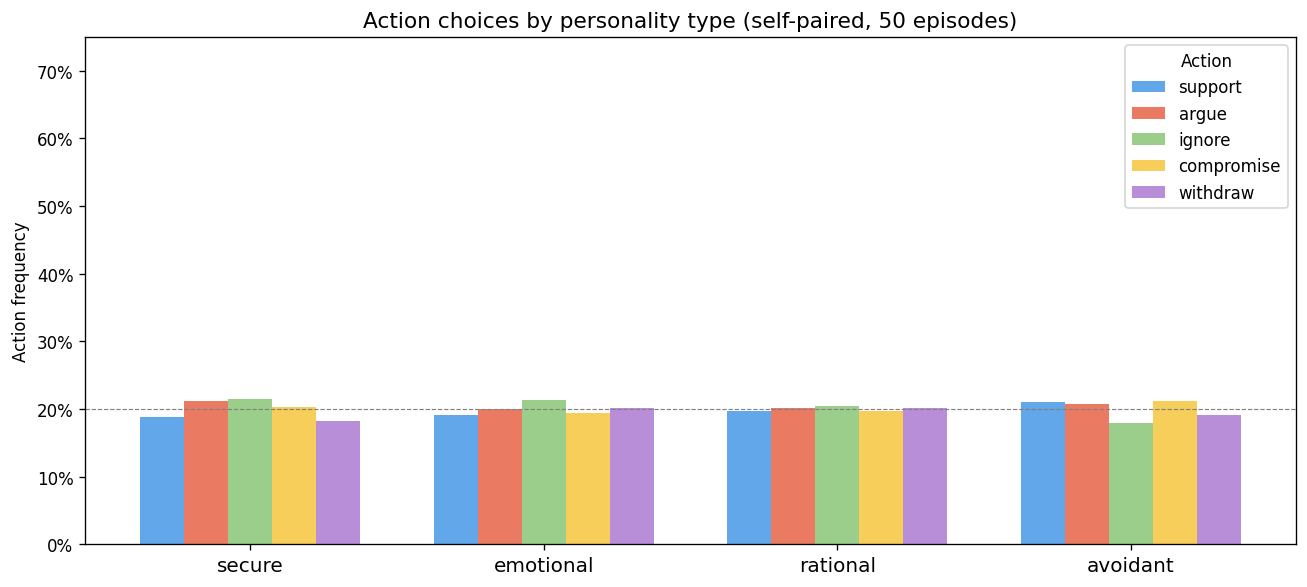

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

x     = np.arange(len(ARCH_NAMES))
width = 0.15

for i, (action, color) in enumerate(zip(ACTION_NAMES, ACTION_COLORS)):
    vals = [
        np.mean([r["action_dist"][i] for r in self_pairs[arch]])
        for arch in ARCH_NAMES
    ]
    ax.bar(x + i * width, vals, width, label=action, color=color, alpha=0.88)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(ARCH_NAMES, fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 0.75)
ax.set_ylabel("Action frequency")
ax.set_title("Action choices by personality type (self-paired, 50 episodes)", fontsize=13)
ax.legend(title="Action", loc="upper right")
ax.axhline(0.20, color="grey", linewidth=0.7, linestyle="--", label="random baseline")

plt.tight_layout()
plt.savefig("data/1_action_distributions.png", dpi=120)
plt.show()

---
## 2 — What outcomes does each personality produce?

Same episodes, now we look at the final Y-state values.

**What to look for:**
- **Emotional** — highest `love_support`, but potentially unstable under pressure
- **Rational** — highest `stability`, but lower emotional warmth
- **Avoidant** — low across the board; disengagement erodes the relationship
- **Secure** — best overall; balanced warmth and stability

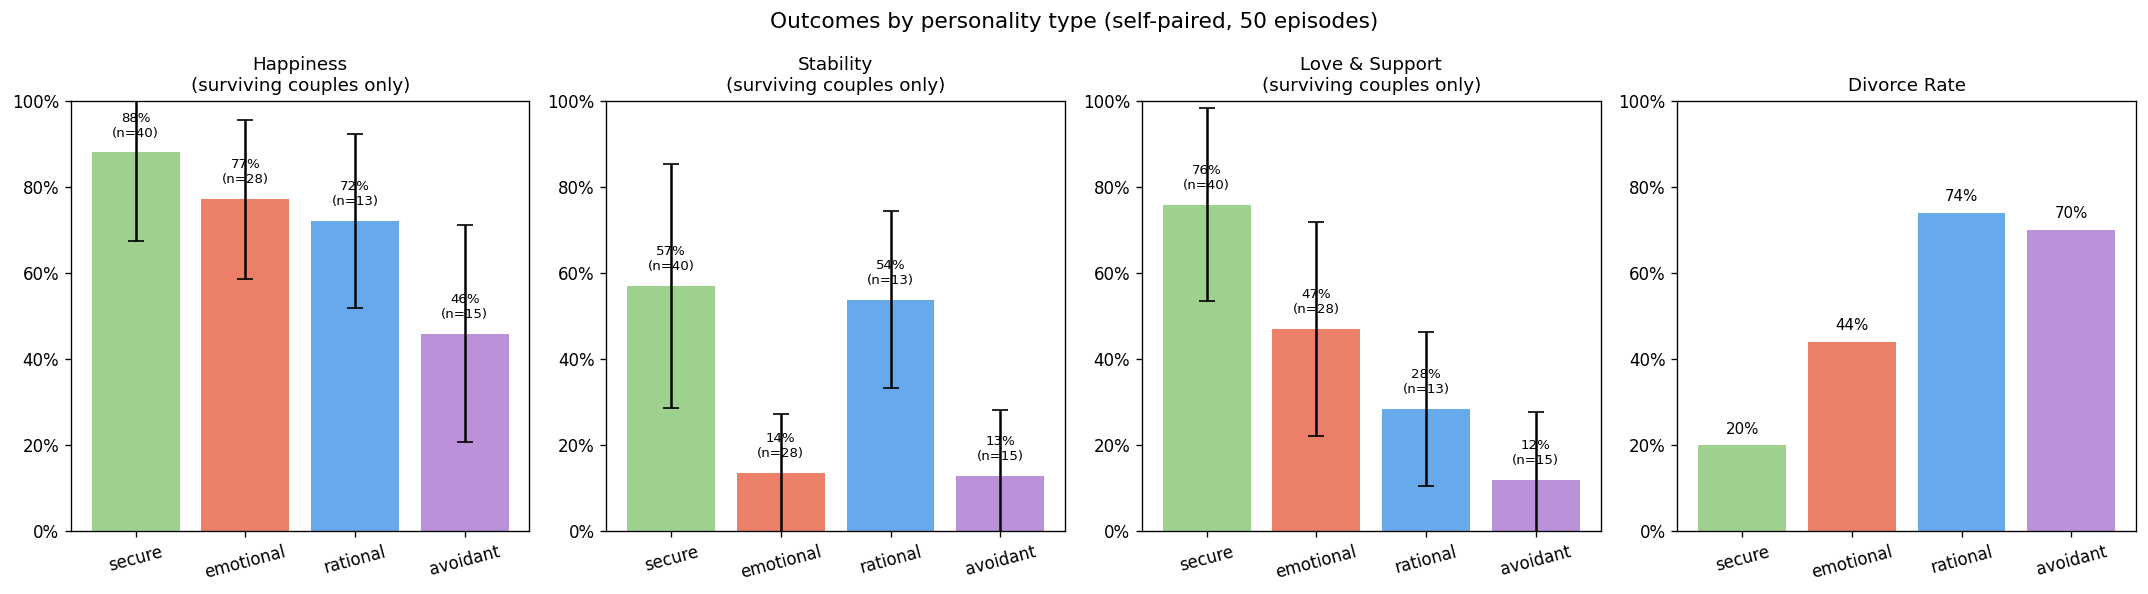

In [7]:
METRICS      = ["happiness", "stability", "love_support"]
METRIC_LABEL = ["Happiness", "Stability", "Love & Support"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Outcomes by personality type (self-paired, 50 episodes)", fontsize=13)

# ── Metrics: surviving couples only ──────────────────────────────────────────
for ax, metric, label in zip(axes[:3], METRICS, METRIC_LABEL):
    survivors = {arch: [r for r in self_pairs[arch] if not r["divorced"]] for arch in ARCH_NAMES}
    means  = [np.mean([r[metric] for r in survivors[arch]]) if survivors[arch] else 0
              for arch in ARCH_NAMES]
    stds   = [np.std( [r[metric] for r in survivors[arch]]) if survivors[arch] else 0
              for arch in ARCH_NAMES]
    n_surv = [len(survivors[arch]) for arch in ARCH_NAMES]
    colors = [ARCH_COLORS[a] for a in ARCH_NAMES]

    bars = ax.bar(ARCH_NAMES, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, error_kw={"linewidth": 1.5})
    ax.set_ylim(0, 1)
    ax.set_title(f"{label}\n(surviving couples only)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.tick_params(axis="x", rotation=15)

    for bar, mean, n in zip(bars, means, n_surv):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.03,
                f"{mean:.0%}\n(n={n})", ha="center", va="bottom", fontsize=8)

# ── Divorce rate ──────────────────────────────────────────────────────────────
ax = axes[3]
divorce_rates = [np.mean([r["divorced"] for r in self_pairs[arch]]) for arch in ARCH_NAMES]
colors = [ARCH_COLORS[a] for a in ARCH_NAMES]
bars = ax.bar(ARCH_NAMES, divorce_rates, color=colors, alpha=0.85)
ax.set_ylim(0, 1)
ax.set_title("Divorce Rate", fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.tick_params(axis="x", rotation=15)
for bar, rate in zip(bars, divorce_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.02,
            f"{rate:.0%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("data/2_outcomes_by_archetype.png", dpi=120)
plt.show()

---
## 3 — Does your partner's personality matter?

We run all 4 × 4 = 16 archetype combinations and plot three outcome heatmaps.
Rows = husband's archetype, columns = wife's archetype.

**What to look for:**
- The diagonal (same-type pairs) isn't always the best
- Emotional + rational may be *complementary* — one brings warmth, the other brings structure
- Avoidant + avoidant should be the worst cell in every heatmap
- Secure pairs best with almost anyone

In [8]:
print("Running all 16 archetype pair combinations (this takes ~2 min)...")

pair_results = {}
for ah in ARCH_NAMES:
    for aw in ARCH_NAMES:
        pair_results[(ah, aw)] = run_pair(ah, aw, n_episodes=40)
        print(f"  {ah} + {aw} done")

print("Done.")

Running all 16 archetype pair combinations (this takes ~2 min)...


  secure + secure done


  secure + emotional done


  secure + rational done


  secure + avoidant done


...

  rational + avoidant done


  avoidant + secure done


  avoidant + emotional done


  avoidant + rational done


  avoidant + avoidant done
Done.


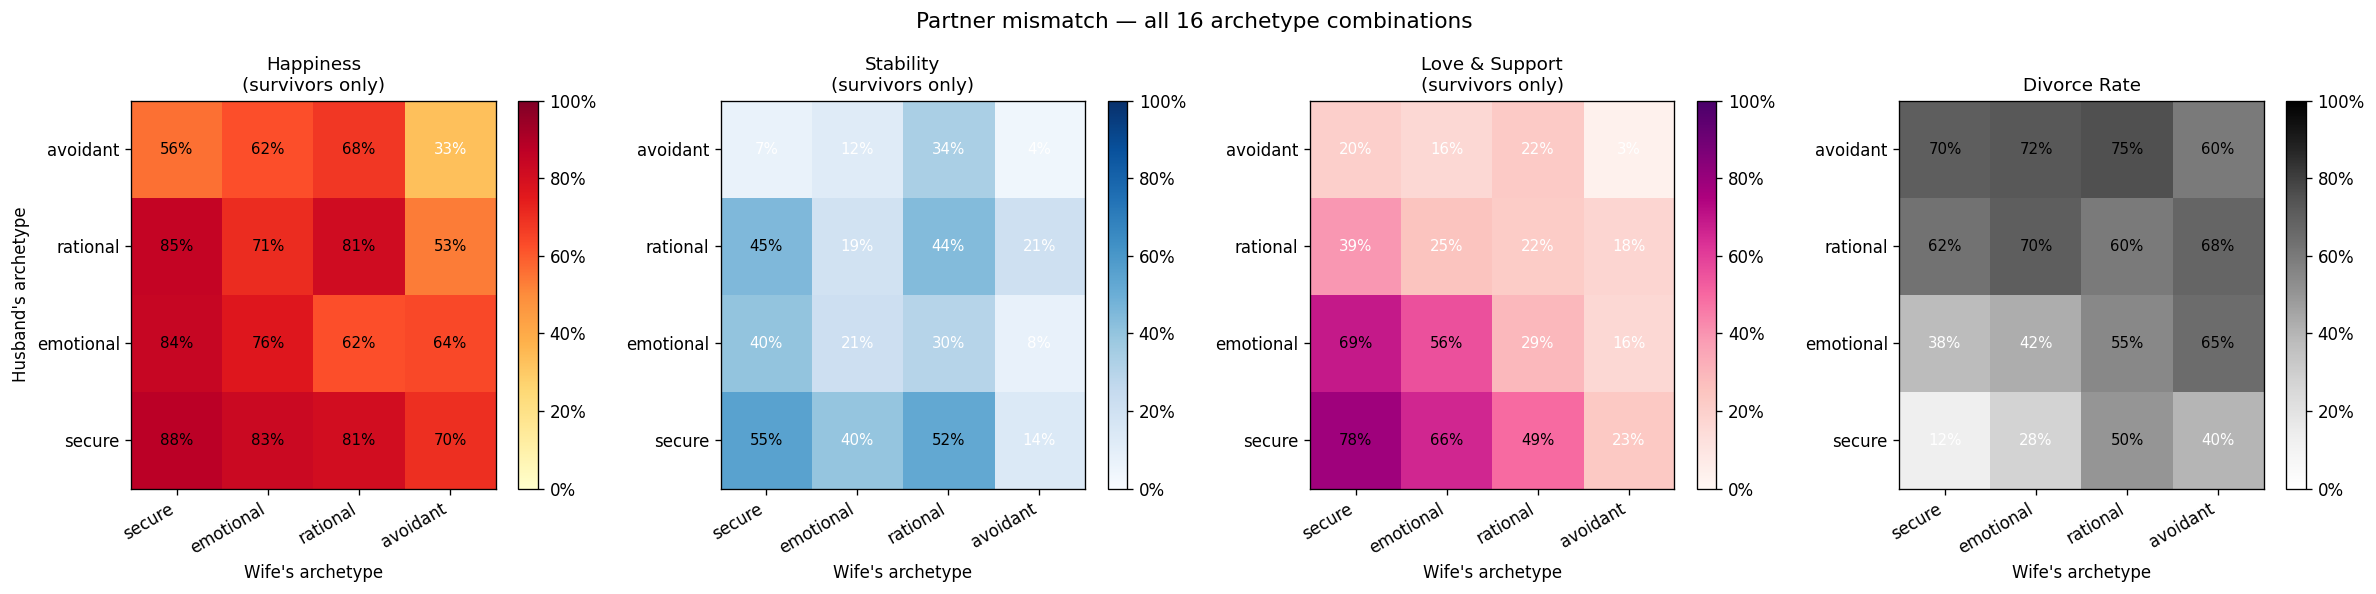

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Partner mismatch — all 16 archetype combinations", fontsize=13)

cmaps        = ["YlOrRd", "Blues", "RdPu", "Greys"]
hmap_metrics = METRICS + ["divorce_rate"]
hmap_labels  = METRIC_LABEL + ["Divorce Rate"]

for ax, metric, label, cmap in zip(axes, hmap_metrics, hmap_labels, cmaps):
    matrix = np.zeros((len(ARCH_NAMES), len(ARCH_NAMES)))
    for i, ah in enumerate(ARCH_NAMES):
        for j, aw in enumerate(ARCH_NAMES):
            recs = pair_results[(ah, aw)]
            if metric == "divorce_rate":
                matrix[i, j] = np.mean([r["divorced"] for r in recs])
            else:
                survivors = [r for r in recs if not r["divorced"]]
                matrix[i, j] = np.mean([r[metric] for r in survivors]) if survivors else 0.0

    im = ax.imshow(matrix, vmin=0, vmax=1, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(ARCH_NAMES)))
    ax.set_yticks(range(len(ARCH_NAMES)))
    ax.set_xticklabels(ARCH_NAMES, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(ARCH_NAMES, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("Wife's archetype")
    if ax is axes[0]:
        ax.set_ylabel("Husband's archetype")
    subtitle = label if metric == "divorce_rate" else f"{label}\n(survivors only)"
    ax.set_title(subtitle, fontsize=11)
    plt.colorbar(im, ax=ax, format=mticker.PercentFormatter(xmax=1))

    for i in range(len(ARCH_NAMES)):
        for j in range(len(ARCH_NAMES)):
            ax.text(j, i, f"{matrix[i,j]:.0%}",
                    ha="center", va="center", fontsize=9,
                    color="white" if matrix[i, j] < 0.45 else "black")

plt.tight_layout()
plt.savefig("data/3_partner_mismatch_heatmaps.png", dpi=120)
plt.show()

---
## 4 — The trade-off: warmth vs stability

Every archetype pair lands somewhere on the love_support ↔ stability spectrum.
This scatter shows whether those two goods can be achieved simultaneously,
or whether every personality profile has to sacrifice one for the other.

**What to look for:** a top-right cluster (high warmth *and* high stability) is the ideal.
Avoidant pairs should land bottom-left. The interesting question is where emotional and rational pairs sit relative to each other.

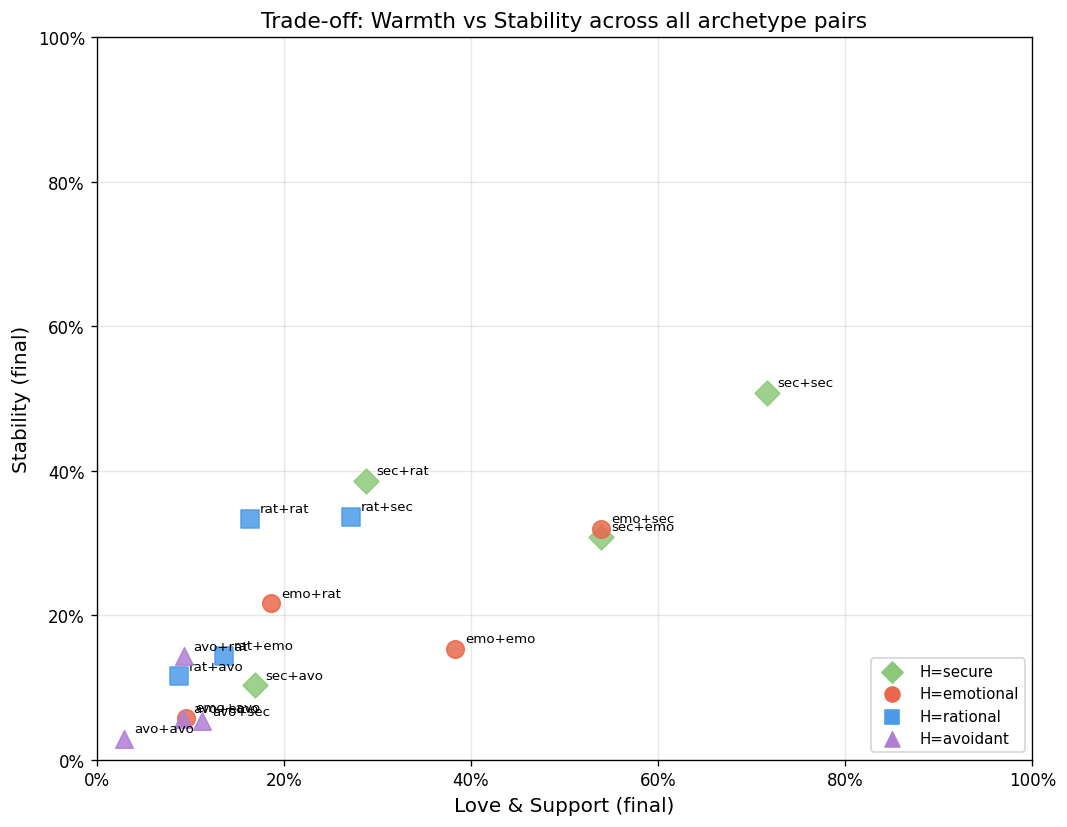

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

for ah in ARCH_NAMES:
    for aw in ARCH_NAMES:
        recs = pair_results[(ah, aw)]
        x_val = np.mean([r["love_support"] for r in recs])
        y_val = np.mean([r["stability"]    for r in recs])
        color = ARCH_COLORS[ah]
        marker = {"emotional": "o", "rational": "s",
                  "avoidant":  "^", "secure":   "D"}[ah]
        ax.scatter(x_val, y_val, color=color, marker=marker,
                   s=110, alpha=0.85, zorder=3)
        label = f"{ah[:3]}+{aw[:3]}"
        ax.annotate(label, (x_val, y_val),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

# Legend for H archetype
for arch in ARCH_NAMES:
    m = {"emotional": "o", "rational": "s", "avoidant": "^", "secure": "D"}[arch]
    ax.scatter([], [], color=ARCH_COLORS[arch], marker=m, label=f"H={arch}", s=80)

ax.set_xlabel("Love & Support (final)", fontsize=12)
ax.set_ylabel("Stability (final)", fontsize=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Trade-off: Warmth vs Stability across all archetype pairs", fontsize=13)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("data/4_warmth_vs_stability.png", dpi=120)
plt.show()

---
## 5 — What does a marriage look like over time?

We trace the mean Y-state trajectory (averaged over 30 episodes) for five
selected pair combinations. This shows *how* outcomes diverge, not just *where* they end up.

**What to look for:**
- Avoidant pairs should show a slow, steady decline
- Secure pairs should stay high and stable
- Emotional + rational may show an interesting crossover: high warmth early, then levelling off

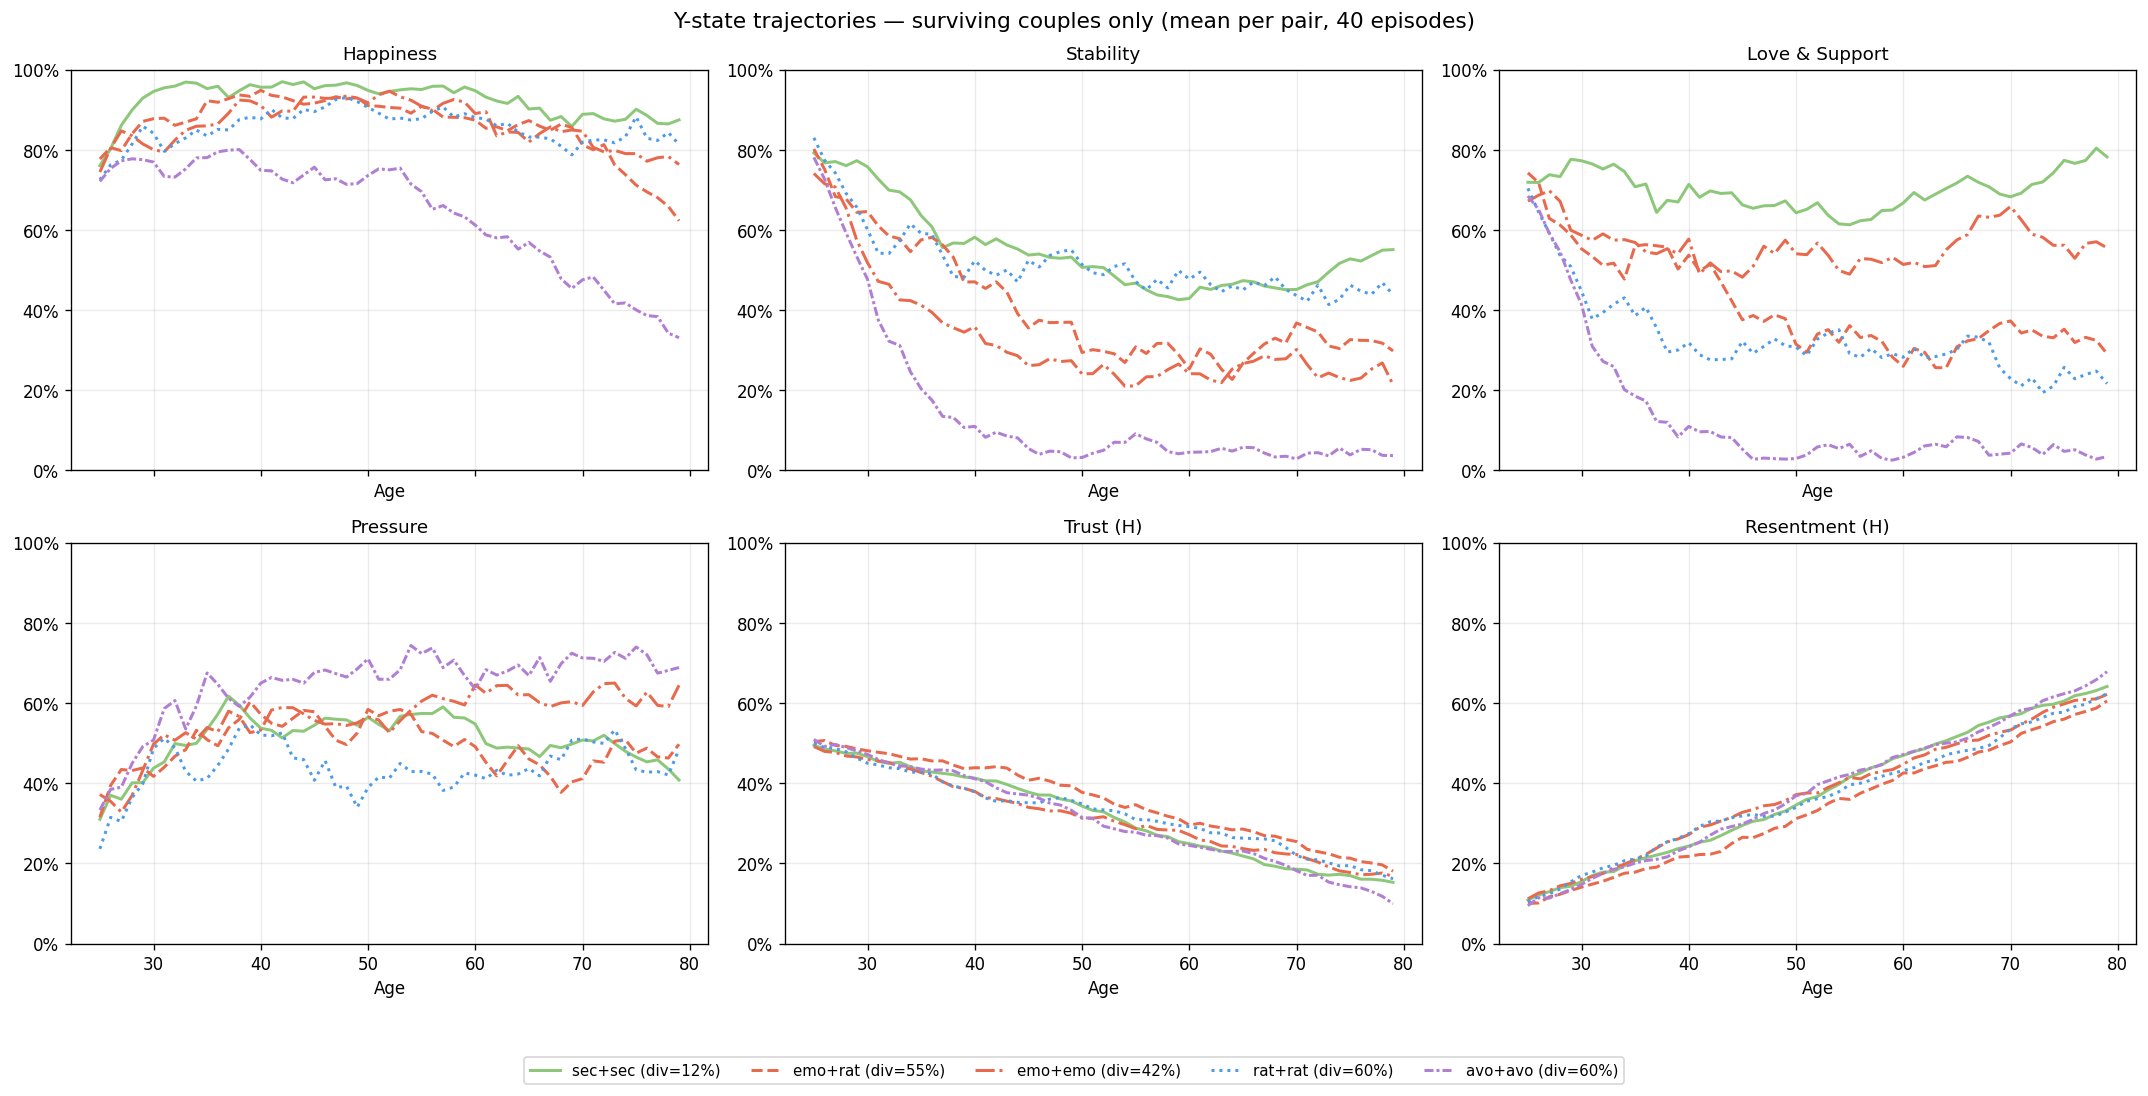

In [11]:
SELECTED_PAIRS = [
    ("secure",    "secure"),
    ("emotional", "rational"),
    ("emotional", "emotional"),
    ("rational",  "rational"),
    ("avoidant",  "avoidant"),
]
PAIR_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
TRAJ_METRICS = ["happiness", "stability", "love_support", "pressure", "trust_h", "resentment_h"]
TRAJ_LABELS  = ["Happiness", "Stability", "Love & Support", "Pressure", "Trust (H)", "Resentment (H)"]

def mean_traj(ah, aw, metric, survivors_only=True):
    recs = pair_results[(ah, aw)]
    if survivors_only:
        recs = [r for r in recs if not r["divorced"]]
    if not recs:
        return np.array([])
    trajs = [r["trajectory"][metric] for r in recs]
    min_len = min(len(t) for t in trajs)
    return np.mean([t[:min_len] for t in trajs], axis=0)

ages = np.arange(env.age_start, env.age_end)

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
fig.suptitle("Y-state trajectories — surviving couples only (mean per pair, 40 episodes)",
             fontsize=13)

for ax, metric, label in zip(axes.flat, TRAJ_METRICS, TRAJ_LABELS):
    for (ah, aw), style in zip(SELECTED_PAIRS, PAIR_STYLES):
        traj = mean_traj(ah, aw, metric, survivors_only=True)
        if len(traj) == 0:
            continue
        div_rate = np.mean([r["divorced"] for r in pair_results[(ah, aw)]])
        pair_label = f"{ah[:3]}+{aw[:3]} (div={div_rate:.0%})"
        color = ARCH_COLORS[ah]
        ax.plot(ages[:len(traj)], traj, linestyle=style,
                color=color, linewidth=1.8, label=pair_label)
    ax.set_ylim(0, 1)
    ax.set_title(label, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel("Age")
    ax.grid(True, alpha=0.25)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(SELECTED_PAIRS),
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("data/5_trajectories.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Summary

| Chart | File | What it shows |
|---|---|---|
| 0 | `data/0_ablation_trained_vs_random.png` | **Policy contribution**: trained vs random baseline — does RL actually matter? |
| 1 | `data/1_action_distributions.png` | Each personality picks different actions |
| 2 | `data/2_outcomes_by_archetype.png` | Outcomes for surviving couples + divorce rate by archetype |
| 3 | `data/3_partner_mismatch_heatmaps.png` | Partner combination matters — includes divorce rate heatmap |
| 4 | `data/4_warmth_vs_stability.png` | The warmth ↔ stability trade-off across all pairs |
| 5 | `data/5_trajectories.png` | How surviving relationships evolve over a lifetime (with divorce rate in legend) |
| 6 | `data/6_life_stage_event_profile.png` | How the event mix shifts across the 55-year lifespan per archetype |

All images are saved to `data/` so you can embed them in a report or presentation.

---
## 6 — How does life stage shape what happens?

We run 200 episodes per archetype (self-paired) and record which event fires at each age.
Events are grouped into categories. The stacked area chart shows how the event mix
shifts across the 55-year lifespan, validating the age-dependent probability system.

**What to look for:**
- Financial stress should dominate early years (25–40)
- Family events (children, parenting conflict) should peak in the 30s–40s
- Health crises and family deaths should rise sharply after 55
- Positive events (quality time, romantic gestures) should persist or grow in later life

Done.


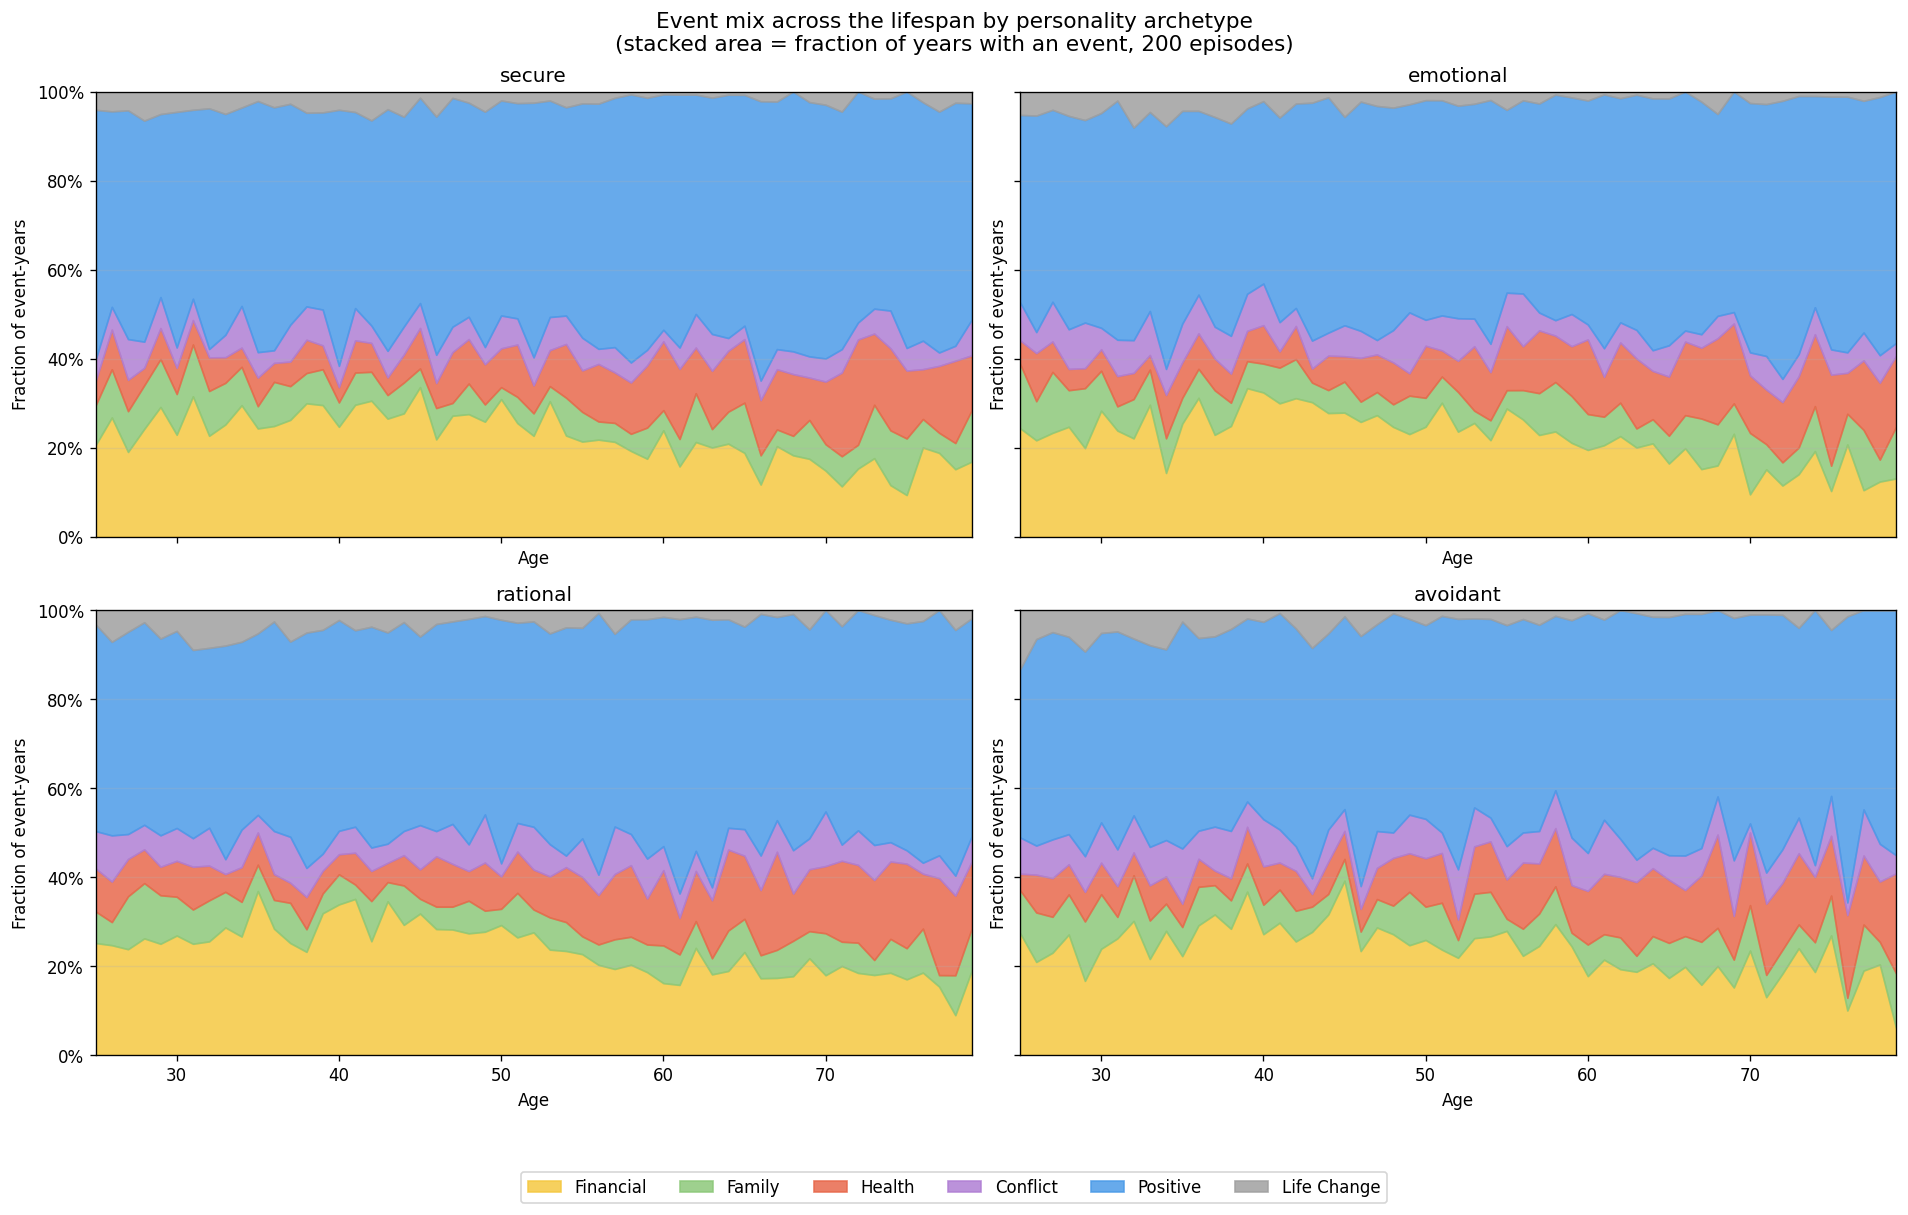

In [12]:
EVENT_CATEGORIES = {
    "Financial":     ["job_loss", "promotion", "financial_crisis", "financial_windfall", "financial_disagreement"],
    "Family":        ["new_child", "parenting_conflict", "family_death"],
    "Health":        ["health_crisis", "mental_health_episode"],
    "Conflict":      ["emotional_conflict", "infidelity"],
    "Positive":      ["romantic_gesture", "quality_time", "everyday_kindness", "shared_achievement"],
    "Life Change":   ["relocation"],
}
CAT_COLORS = {
    "Financial":   "#F5C842",
    "Family":      "#8DC87A",
    "Health":      "#E8694C",
    "Conflict":    "#B07FD4",
    "Positive":    "#4C9BE8",
    "Life Change": "#A0A0A0",
}
N_STAGE_EPISODES = 200

def collect_event_by_age(arch, n_episodes=N_STAGE_EPISODES, seed=99):
    """Return a dict {age: Counter(event_name)} over n_episodes."""
    np.random.seed(seed)
    th = ARCHETYPES[arch]
    age_events = {age: Counter() for age in range(env.age_start, env.age_end)}

    for _ in range(n_episodes):
        env.reset()
        _inject(th, th)
        obs_h = env._get_obs("h")
        obs_w = env._get_obs("w")
        done  = False
        while not done:
            ah, _, _ = agent_h.act(obs_h)
            aw, _, _ = agent_w.act(obs_w)
            obs_h, _, done, _, info = env.step([ah, aw])
            obs_w = info["obs_w"]
            # info["age"] is post-step age; event was sampled for this step's age
            step_age = info["age"] - 1
            if step_age in age_events and info["event"] != "none":
                age_events[step_age][info["event"]] += 1
    return age_events

print("Collecting life-stage event data (this takes ~1 min)...")
stage_data = {arch: collect_event_by_age(arch) for arch in ARCH_NAMES}
print("Done.")

# ── Plot: stacked area per archetype ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
fig.suptitle("Event mix across the lifespan by personality archetype\n"
             f"(stacked area = fraction of years with an event, {N_STAGE_EPISODES} episodes)",
             fontsize=13)

ages = list(range(env.age_start, env.age_end))

for ax, arch in zip(axes.flat, ARCH_NAMES):
    age_events = stage_data[arch]
    # Total events per age (for normalisation)
    totals = np.array([sum(age_events[a].values()) for a in ages], dtype=float)
    totals = np.where(totals == 0, 1, totals)  # avoid divide-by-zero

    bottom = np.zeros(len(ages))
    for cat, event_names in EVENT_CATEGORIES.items():
        counts = np.array(
            [sum(age_events[a].get(e, 0) for e in event_names) for a in ages],
            dtype=float,
        )
        fracs = counts / totals
        ax.fill_between(ages, bottom, bottom + fracs,
                        color=CAT_COLORS[cat], alpha=0.85, label=cat)
        bottom += fracs

    ax.set_title(arch, fontsize=12)
    ax.set_xlim(env.age_start, env.age_end - 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Age")
    ax.set_ylabel("Fraction of event-years")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.grid(axis="y", alpha=0.25)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(EVENT_CATEGORIES),
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("data/6_life_stage_event_profile.png", dpi=120, bbox_inches="tight")
plt.show()